In [8]:
import numpy as np
import pyfar as pf
import sparrowpy as sp
import matplotlib.pyplot as plt
import spharpy
import utils
import os
import sofar as sf
%matplotlib inline
# %matplotlib ipympl


In [9]:
# read simulation results
root_dir = utils.path.repository_root()
data_path = os.path.join(root_dir, 'data', 'bras_scene_far')
path_impulse_response_numerical = os.path.join(data_path, 'bras_sample.ir.sofa')

sofa = sf.read_sofa(path_impulse_response_numerical)
data, sources, receivers = pf.io.convert_sofa(sofa)

SOFA file contained custom entries
----------------------------------
SampleStructuralWavelength, SampleStructuralWavelengthX, SampleStructuralWavelengthY, SampleModelScale, SampleDiameter, SpeedOfSound, DensityOfMedium, ReceiverWeights, SourceWeights, SampleSymmetryAzimuth, SampleSymmetryRotational


In [10]:
# read analytical BRDF
path_analytical_brdf = os.path.join(root_dir, 'data', 'analytic', 'rect_analytical.E_octave.sofa')
sofa_brdf = sf.read_sofa(path_analytical_brdf)

bsc, bsc_sources, bsc_receivers = pf.io.convert_sofa(sofa_brdf)
bsc_sources.weights = np.sin(bsc_sources.elevation)
bsc_receivers.weights = np.sin(bsc_receivers.elevation)


ValueError: /Users/riopradipto/Documents/cloudsync/MASTERARBEITnew/Framework/Numerical/2025_simulation_bras/data/analytic/rect_analytical.E_octave.sofa does not exist

In [ ]:
#source and receiver positions
source = pf.Coordinates(2, 2, 2)
receiver = pf.Coordinates(2, 4, 2)
source = sources[0]
receiver = receivers


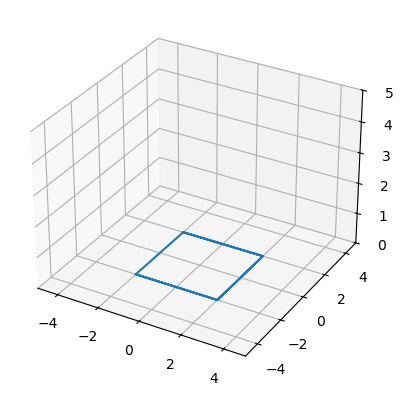

4000.0


In [ ]:
# Define parameters
length_x = 4
length_y = 4
Z = 4

patch_size = 1

sampling_rate = data.sampling_rate
etc_duration = data.n_bins/sampling_rate
etc_time_resolution = 1/sampling_rate

max_reflection_order = 10
speed_of_sound = sofa.SpeedOfSound
absorption = 0.1

# create flat surface geometry
walls = []
surface = sp.geometry.Polygon(
            [[-length_x/2, -length_y/2, 0], [length_x/2, -length_y/2, 0],
            [length_x/2, length_y/2, 0], [-length_x/2, length_y/2, 0]],
            [1, 0, 0], [0, 0, 1])
walls = [surface]

#source and receiver positions


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(0, 5)
surface.plot(ax)

plt.show()

#create frequency range
band = 1
freq_lower = 20
freq_upper = data.sampling_rate/2



In [ ]:
#Plot the environment 

env = sp.geometry.Environment(walls, source, receiver, speed_of_sound=speed_of_sound)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot polygons in the environment
for poly in env.polygons:
    poly.plot(ax)

# Plot source and receiver positions
ax.scatter(env.source.x, env.source.y, env.source.z, color='r', label='Source')
ax.scatter(env.receiver.x, env.receiver.y, env.receiver.z, color='b', label='Receiver')

ax.legend()
plt.show()
    

In [ ]:
radiosity_fast = sp.DirectionalRadiosityFast.from_polygon(walls, patch_size)

In [ ]:
frequency_data = pf.dsp.filter.fractional_octave_frequencies(band,(freq_lower,freq_upper))
frequency_data = frequency_data[0]
scattering_data = np.ones_like(frequency_data)
print(frequency_data)
print(scattering_data)

In [ ]:
#BRDF incoming and outgoing directions (source and receiver) set to the same positions

#BRDF_resolution = spharpy.samplings.gaussian(n_max = 17).to_pyfar()
#BRDF_resolution = BRDF_resolution[BRDF_resolution.z>0]
#brdf_incoming = BRDF_resolution
#brdf_outgoing = BRDF_resolution



fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(bsc_receivers.x, bsc_receivers.y, bsc_receivers.z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('BRDF Sampling Directions')
plt.show()

In [ ]:
frequency_data = pf.dsp.filter.fractional_octave_frequencies(band,(freq_lower,freq_upper))[0]

brdf_bidir = sp.brdf.create_from_directional_scattering(bsc_sources, bsc_receivers, bsc)


In [ ]:
radiosity_fast.set_wall_scattering(np.arange(len(walls)), brdf_bidir, bsc_sources, bsc_receivers)

radiosity_fast.set_air_attenuation(
    pf.FrequencyData(
        np.zeros_like(brdf_bidir.frequencies),
        brdf_bidir.frequencies))

# set absorption coefficient
radiosity_fast.set_wall_absorption(
    np.arange(len(walls)),
    pf.FrequencyData(
        np.zeros_like(brdf_bidir.frequencies)+absorption,
        brdf_bidir.frequencies))

In [ ]:
radiosity_fast.init_source_energy(source)

In [ ]:
# gather energy at receiver
radiosity_fast.calculate_energy_exchange(
    speed_of_sound=speed_of_sound,
    histogram_time_resolution=etc_time_resolution,
    histogram_length=etc_duration,
    max_depth=max_reflection_order)

In [ ]:

ir_fast = np.sum(radiosity_fast.collect_receiver_energy(
    receiver_pos=receiver,
    speed_of_sound=speed_of_sound,
    histogram_time_resolution=etc_time_resolution,
    propagation_fx=True,
    ),axis=1)[0]
n_samples = ir_fast.shape[-1]
reverberation_fast = pf.TimeData(ir_fast, etc_duration)
print(reverberation_fast)